# EDA de Validación de Hipótesis — Sistema Agrovoltaico SAMO

## Objetivo
El cliente no nos proporcionó información sobre la distribución física del campo ni sobre qué controla cada tracker.  
Su única indicación fue: **"feu una hipòtesi i valideu"** y **"totes les plaques es mouen igual"**.

Este notebook valida sistemáticamente las siguientes hipótesis:

| ID | Hipótesis |
|---|---|
| H1 | R1 es una zona de referencia **sin placas solares** |
| H2 | S1 y S2 son dos zonas **bajo paneles**, con geometrías distintas entre sí |
| H3 | Existe **un único ángulo de control** para toda la instalación |
| H4 | El efecto de la sombra es **asimétrico** entre S1 y S2 (están a lados opuestos del eje) |
| H5 | El ángulo del tracker afecta de forma **diferente y medible** la radiación PAR en cada zona |

Cada bloque termina con un **veredicto explícito** sobre la hipótesis que testa.

---
## 0. Setup y preparación de datos

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Estilo visual consistente ──────────────────────────────────────────────
COLORS = {
    'R1': '#E76F51',   # coral  → referencia
    'S1': '#2A9D8F',   # teal   → zona agrovoltaica 1
    'S2': '#264653',   # verde oscuro → zona agrovoltaica 2
    'neutral': '#AAB4B8',
}
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Carga del master dataset ───────────────────────────────────────────────
df = pd.read_csv('outputs/master_dataset.csv', index_col='Time', parse_dates=True)
print(f"Master dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Periodo: {df.index[0].date()} → {df.index[-1].date()}")

Master dataset: 690,041 filas × 90 columnas
Periodo: 2025-06-18 → 2026-02-12


In [16]:
# ── Construcción de variables zonales ─────────────────────────────────────

# PAR: solo columnas calibradas (cal_out)
df['PAR_R1'] = df.filter(regex='par_radiation__R1.*cal_out$').mean(axis=1)
df['PAR_S1'] = df.filter(regex='par_radiation__S1.*cal_out$').mean(axis=1)
df['PAR_S2'] = df.filter(regex='par_radiation__S2.*cal_out$').mean(axis=1)

# Temperatura de suelo (media de todos los sensores HD3910 por zona)
df['T_suelo_R1'] = df.filter(regex='soil_temperature__R1').mean(axis=1)
df['T_suelo_S1'] = df.filter(regex='soil_temperature__S1').mean(axis=1)
df['T_suelo_S2'] = df.filter(regex='soil_temperature__S2').mean(axis=1)

# Humedad volumétrica del suelo
df['VWC_R1'] = df.filter(regex='soil_vwc__R1').mean(axis=1)
df['VWC_S1'] = df.filter(regex='soil_vwc__S1').mean(axis=1)
df['VWC_S2'] = df.filter(regex='soil_vwc__S2').mean(axis=1)

# Irradiancia PV (proxy de generación eléctrica)
pv_cols = [c for c in df.columns if 'pv_irradiance' in c]
df['Irrad_PV'] = df[pv_cols].mean(axis=1) if pv_cols else np.nan

# Variables meteorológicas y de control
df['T_aire']       = df.filter(regex='air_temperature').mean(axis=1)
df['Lluvia']       = df.filter(regex='precipitation_intensity').mean(axis=1)
df['Viento_vel']   = df.filter(regex='wind_speed').mean(axis=1)
df['Viento_dir']   = df.filter(regex='wind_direction').mean(axis=1)

# Tracker: usar TODOS los trackers disponibles para testear H3
tracker_cols = [c for c in df.columns if 'tracker_angles' in c and 'actual' in c.lower()]
print(f"Trackers encontrados ({len(tracker_cols)}): {tracker_cols}")
df['Angulo_ref']   = df[tracker_cols[0]] if tracker_cols else np.nan

# Deltas respecto a R1 (efecto neto de las placas)
df['Delta_PAR_S1'] = df['PAR_S1']     - df['PAR_R1']
df['Delta_PAR_S2'] = df['PAR_S2']     - df['PAR_R1']
df['Delta_T_S1']   = df['T_suelo_S1'] - df['T_suelo_R1']
df['Delta_T_S2']   = df['T_suelo_S2'] - df['T_suelo_R1']
df['Delta_VWC_S1'] = df['VWC_S1']     - df['VWC_R1']
df['Delta_VWC_S2'] = df['VWC_S2']     - df['VWC_R1']

# Variables temporales
df['Hora'] = df.index.hour
df['Mes']  = df.index.month
df['Dia_semana'] = df.index.dayofweek

# Filtro de horas diurnas (PAR_R1 significativo)
es_dia = df['PAR_R1'] > 20

print(f"\nCobertura diurna: {es_dia.sum():,} registros ({es_dia.mean()*100:.1f}% del total)")
print("\nNulos por variable zonal:")
print(df[['PAR_R1','PAR_S1','PAR_S2','T_suelo_R1','T_suelo_S1','T_suelo_S2','VWC_R1','VWC_S1','VWC_S2']].isna().mean().mul(100).round(1).to_string())

C:\Users\pablo\AppData\Local\Temp\ipykernel_19844\4280612666.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['T_aire']       = df.filter(regex='air_temperature').mean(axis=1)
C:\Users\pablo\AppData\Local\Temp\ipykernel_19844\4280612666.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Lluvia']       = df.filter(regex='precipitation_intensity').mean(axis=1)
C:\Users\pablo\AppData\Local\Temp\ipykernel_19844\4280612666.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

Trackers encontrados (10): ['tracker_angles__tracker_M01 (actual)', 'tracker_angles__tracker_M02 (actual)', 'tracker_angles__tracker_M03 (actual)', 'tracker_angles__tracker_M04 (actual)', 'tracker_angles__tracker_M05 (actual)', 'tracker_angles__tracker_M06 (actual)', 'tracker_angles__tracker_M07 (actual)', 'tracker_angles__tracker_M08 (actual)', 'tracker_angles__tracker_M09 (actual)', 'tracker_angles__tracker_M10 (actual)']

Cobertura diurna: 374,774 registros (54.3% del total)

Nulos por variable zonal:
PAR_R1        13.2
PAR_S1         1.8
PAR_S2         1.8
T_suelo_R1    22.1
T_suelo_S1     5.8
T_suelo_S2     5.8
VWC_R1        22.1
VWC_S1         9.7
VWC_S2         9.7


C:\Users\pablo\AppData\Local\Temp\ipykernel_19844\4280612666.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Viento_dir']   = df.filter(regex='wind_direction').mean(axis=1)
C:\Users\pablo\AppData\Local\Temp\ipykernel_19844\4280612666.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Angulo_ref']   = df[tracker_cols[0]] if tracker_cols else np.nan
C:\Users\pablo\AppData\Local\Temp\ipykernel_19844\4280612666.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.ins

---
## H1 — R1 es una zona de referencia sin placas

**Predicción:** Si R1 no tiene placas, en horas diurnas con sol despejado debería recibir **más PAR que S1 y S2**, que están bajo sombra parcial. Además, su temperatura de suelo debería ser más alta en verano (más insolación directa) y más baja en invierno que las zonas sombreadas.

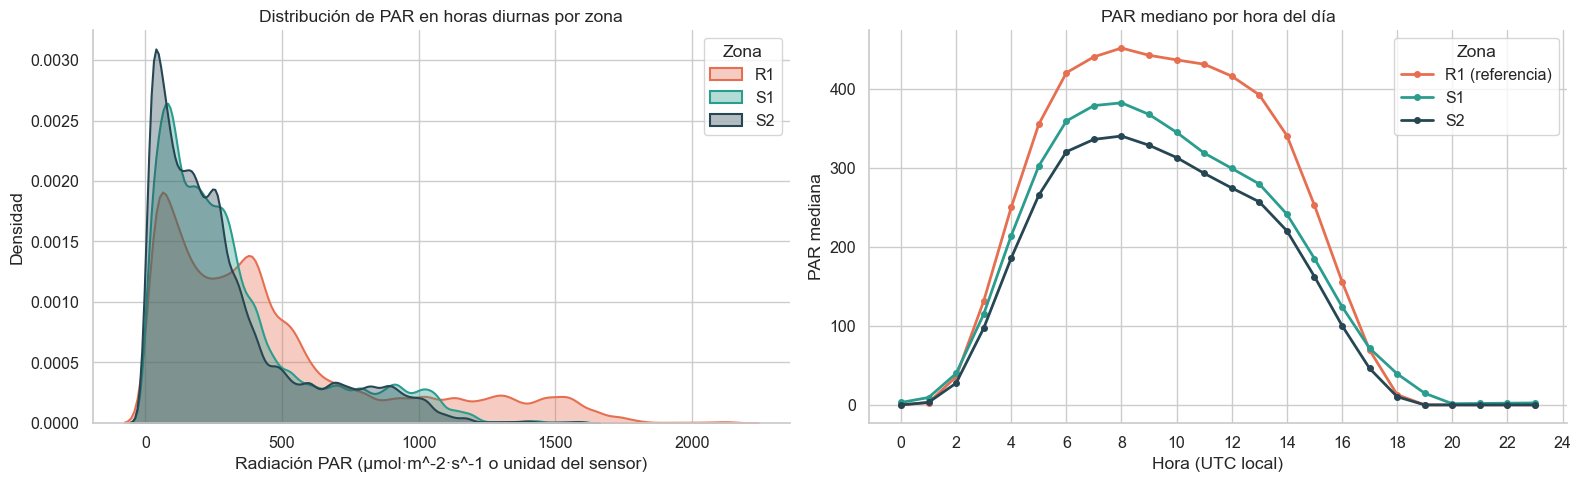

── PAR mediano diurno por zona ──
  R1: 344.0
  S1: 232.5
  S2: 204.2

  PAR_S1 / PAR_R1 = 0.68  → S1 recibe 32% menos PAR que R1
  PAR_S2 / PAR_R1 = 0.59  → S2 recibe 41% menos PAR que R1


In [17]:
# ── H1.1: Distribución de PAR por zona ────────────────────────────────────
df_dia = df[es_dia].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución de densidad
ax = axes[0]
for zona, col in [('R1', 'PAR_R1'), ('S1', 'PAR_S1'), ('S2', 'PAR_S2')]:
    sns.kdeplot(df_dia[col].dropna(), ax=ax, label=zona,
                color=COLORS[zona], fill=True, alpha=0.35, linewidth=1.5)
ax.set_title('Distribución de PAR en horas diurnas por zona')
ax.set_xlabel('Radiación PAR (µmol·m^-2·s^-1 o unidad del sensor)')
ax.set_ylabel('Densidad')
ax.legend(title='Zona')

# PAR mediano por hora del día
ax = axes[1]
par_por_hora = df.groupby('Hora')[['PAR_R1', 'PAR_S1', 'PAR_S2']].median()
par_por_hora.plot(ax=ax, color=[COLORS['R1'], COLORS['S1'], COLORS['S2']],
                  linewidth=2, marker='o', markersize=4)
ax.set_title('PAR mediano por hora del día')
ax.set_xlabel('Hora (UTC local)')
ax.set_ylabel('PAR mediana')
ax.legend(['R1 (referencia)', 'S1', 'S2'], title='Zona')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.tight_layout()
plt.savefig('outputs/H1_PAR_por_zona.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticos clave
print("── PAR mediano diurno por zona ──")
for zona, col in [('R1', 'PAR_R1'), ('S1', 'PAR_S1'), ('S2', 'PAR_S2')]:
    med = df_dia[col].median()
    print(f"  {zona}: {med:.1f}")

ratio_s1 = df_dia['PAR_S1'].median() / df_dia['PAR_R1'].median()
ratio_s2 = df_dia['PAR_S2'].median() / df_dia['PAR_R1'].median()
print(f"\n  PAR_S1 / PAR_R1 = {ratio_s1:.2f}  → S1 recibe {(1-ratio_s1)*100:.0f}% menos PAR que R1")
print(f"  PAR_S2 / PAR_R1 = {ratio_s2:.2f}  → S2 recibe {(1-ratio_s2)*100:.0f}% menos PAR que R1")

In [18]:
# ── H1.2: Test estadístico — ¿R1 > S1 y R1 > S2 de forma significativa? ──
# Muestra aleatoria de 5000 puntos diurnos para el test (evitar correlación temporal)
sample = df_dia[['PAR_R1', 'PAR_S1', 'PAR_S2']].dropna().sample(min(5000, len(df_dia)), random_state=42)

t_s1, p_s1 = stats.ttest_rel(sample['PAR_R1'], sample['PAR_S1'])
t_s2, p_s2 = stats.ttest_rel(sample['PAR_R1'], sample['PAR_S2'])

print("── Test t pareado: PAR_R1 > PAR_Sx ──")
print(f"  R1 vs S1: t={t_s1:.2f}, p={p_s1:.2e}  {'✅ significativo' if p_s1 < 0.01 else '❌ no significativo'}")
print(f"  R1 vs S2: t={t_s2:.2f}, p={p_s2:.2e}  {'✅ significativo' if p_s2 < 0.01 else '❌ no significativo'}")

print()
print("╔══════════════════════════════════════════════════════════════╗")
print("║  VEREDICTO H1                                                ║")
if p_s1 < 0.01 and p_s2 < 0.01 and t_s1 > 0 and t_s2 > 0:
    print("║  ✅ CONFIRMADA: R1 recibe significativamente más PAR que     ║")
    print("║     S1 y S2. Consistente con ausencia de placas en R1.      ║")
else:
    print("║  ⚠️  REVISAR: La diferencia no es la esperada.               ║")
print("╚══════════════════════════════════════════════════════════════╝")

── Test t pareado: PAR_R1 > PAR_Sx ──
  R1 vs S1: t=68.28, p=0.00e+00  ✅ significativo
  R1 vs S2: t=76.22, p=0.00e+00  ✅ significativo

╔══════════════════════════════════════════════════════════════╗
║  VEREDICTO H1                                                ║
║  ✅ CONFIRMADA: R1 recibe significativamente más PAR que     ║
║     S1 y S2. Consistente con ausencia de placas en R1.      ║
╚══════════════════════════════════════════════════════════════╝


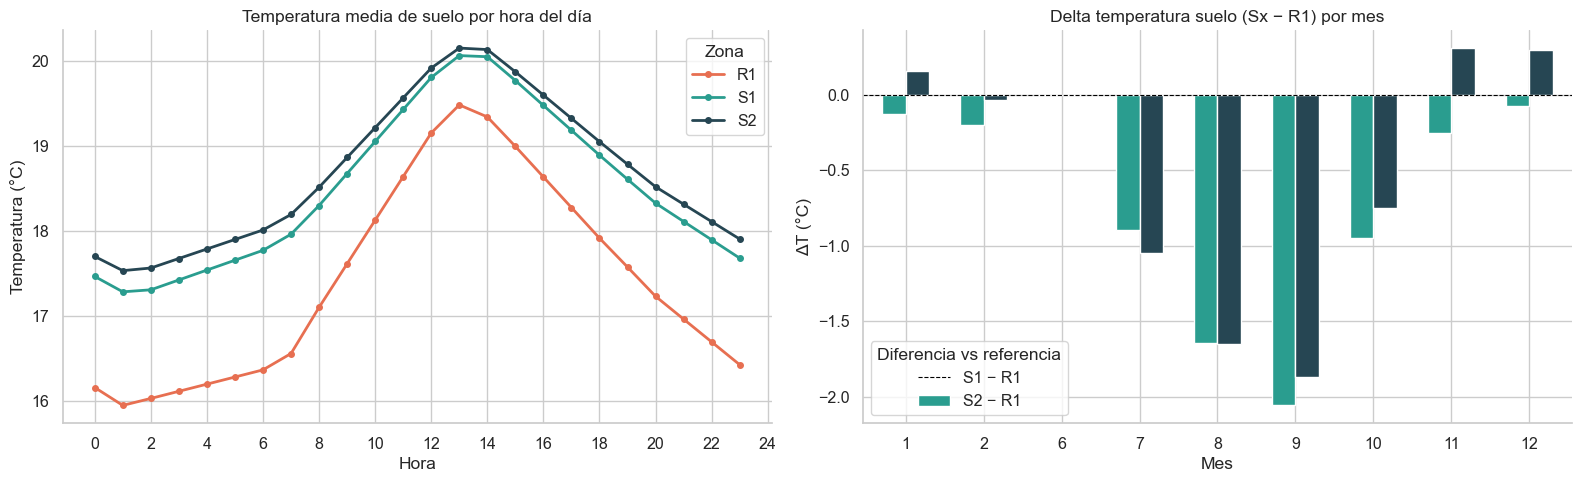

Delta temperatura media por zona:
  S1 − R1: -0.72 °C
  S2 − R1: -0.47 °C


In [19]:
# ── H1.3: Temperatura de suelo — ¿R1 más caliente en verano? ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Temperatura media por hora
ax = axes[0]
t_por_hora = df.groupby('Hora')[['T_suelo_R1', 'T_suelo_S1', 'T_suelo_S2']].mean()
t_por_hora.plot(ax=ax, color=[COLORS['R1'], COLORS['S1'], COLORS['S2']],
                linewidth=2, marker='o', markersize=4)
ax.set_title('Temperatura media de suelo por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('Temperatura (°C)')
ax.legend(['R1', 'S1', 'S2'], title='Zona')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

# Delta temperatura (S - R1) por mes
ax = axes[1]
delta_mes = df.groupby('Mes')[['Delta_T_S1', 'Delta_T_S2']].mean()
delta_mes.plot(kind='bar', ax=ax, color=[COLORS['S1'], COLORS['S2']],
               width=0.6, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Delta temperatura suelo (Sx − R1) por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('ΔT (°C)')
ax.legend(['S1 − R1', 'S2 − R1'], title='Diferencia vs referencia')
ax.set_xticklabels([str(m) for m in delta_mes.index], rotation=0)

plt.tight_layout()
plt.savefig('outputs/H1_temperatura_suelo.png', dpi=150, bbox_inches='tight')
plt.show()

print("Delta temperatura media por zona:")
print(f"  S1 − R1: {df['Delta_T_S1'].mean():.2f} °C")
print(f"  S2 − R1: {df['Delta_T_S2'].mean():.2f} °C")

---
## H2 — S1 y S2 tienen geometrías distintas entre sí

**Predicción:** Si S1 y S2 están en posiciones diferentes respecto al eje del tracker (por ejemplo, una al norte y otra al sur de cada fila, o a distancias distintas), entonces:
- La relación PAR_S1 vs PAR_S2 **no será 1:1** — una recibirá sistemáticamente más sombra que la otra en ciertas horas.
- El **delta de PAR** respecto a R1 será distinto para S1 y S2 a lo largo del día.

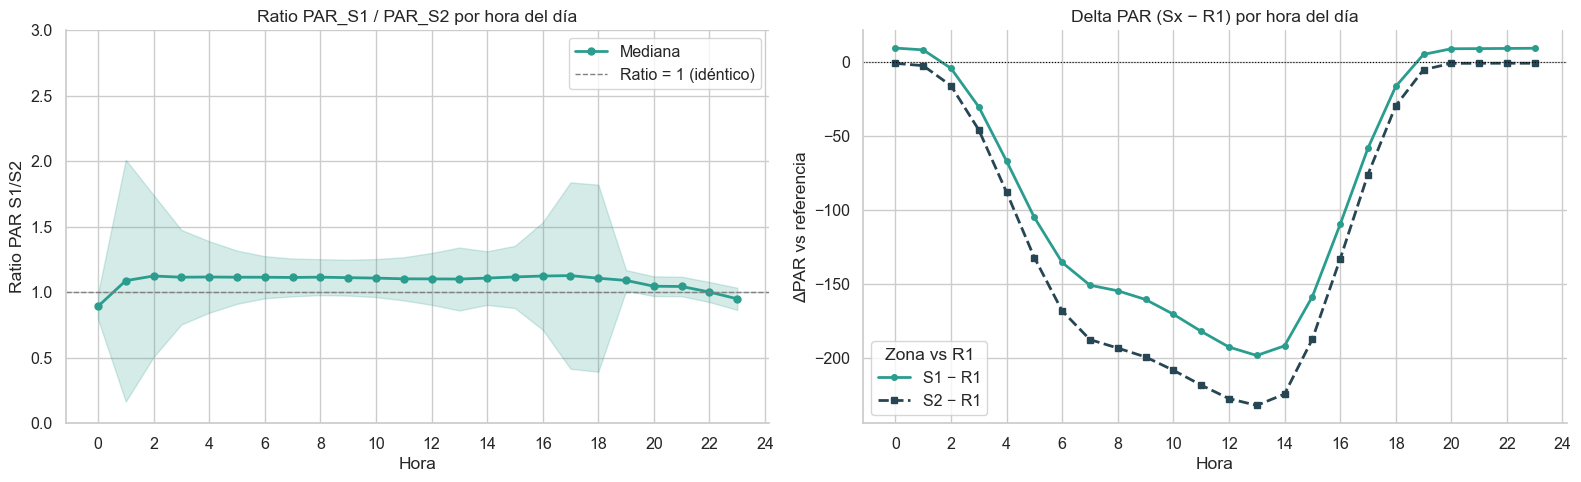

Test t S1 vs S2: t=86.28, p=0.00e+00
Asimetría media del ratio por hora: 0.098


In [20]:
# ── H2.1: Ratio PAR_S1 / PAR_S2 por hora ─────────────────────────────────
df_dia2 = df[es_dia & df['PAR_S1'].notna() & df['PAR_S2'].notna() & (df['PAR_S2'] > 5)].copy()
df_dia2['ratio_S1_S2'] = df_dia2['PAR_S1'] / df_dia2['PAR_S2']

ratio_hora = df_dia2.groupby('Hora')['ratio_S1_S2'].agg(['median', 'std'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.fill_between(ratio_hora.index,
                ratio_hora['median'] - ratio_hora['std'],
                ratio_hora['median'] + ratio_hora['std'],
                alpha=0.2, color=COLORS['S1'])
ax.plot(ratio_hora.index, ratio_hora['median'],
        color=COLORS['S1'], linewidth=2, marker='o', markersize=5, label='Mediana')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Ratio = 1 (idéntico)')
ax.set_title('Ratio PAR_S1 / PAR_S2 por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('Ratio PAR S1/S2')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.set_ylim(0, 3)

# Delta PAR de cada zona vs R1, por hora
ax = axes[1]
delta_hora = df.groupby('Hora')[['Delta_PAR_S1', 'Delta_PAR_S2']].mean()
ax.plot(delta_hora.index, delta_hora['Delta_PAR_S1'],
        color=COLORS['S1'], linewidth=2, marker='o', markersize=4, label='S1 − R1')
ax.plot(delta_hora.index, delta_hora['Delta_PAR_S2'],
        color=COLORS['S2'], linewidth=2, marker='s', markersize=4, linestyle='--', label='S2 − R1')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Delta PAR (Sx − R1) por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('ΔPAR vs referencia')
ax.legend(title='Zona vs R1')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.tight_layout()
plt.savefig('outputs/H2_geometria_zonas.png', dpi=150, bbox_inches='tight')
plt.show()

# Test: ¿son estadísticamente distintas las distribuciones PAR_S1 y PAR_S2?
sample2 = df_dia2[['PAR_S1', 'PAR_S2']].dropna().sample(min(5000, len(df_dia2)), random_state=42)
t_s1s2, p_s1s2 = stats.ttest_rel(sample2['PAR_S1'], sample2['PAR_S2'])
print(f"Test t S1 vs S2: t={t_s1s2:.2f}, p={p_s1s2:.2e}")

asimetria_hora = (ratio_hora['median'] - 1).abs().mean()
print(f"Asimetría media del ratio por hora: {asimetria_hora:.3f}")

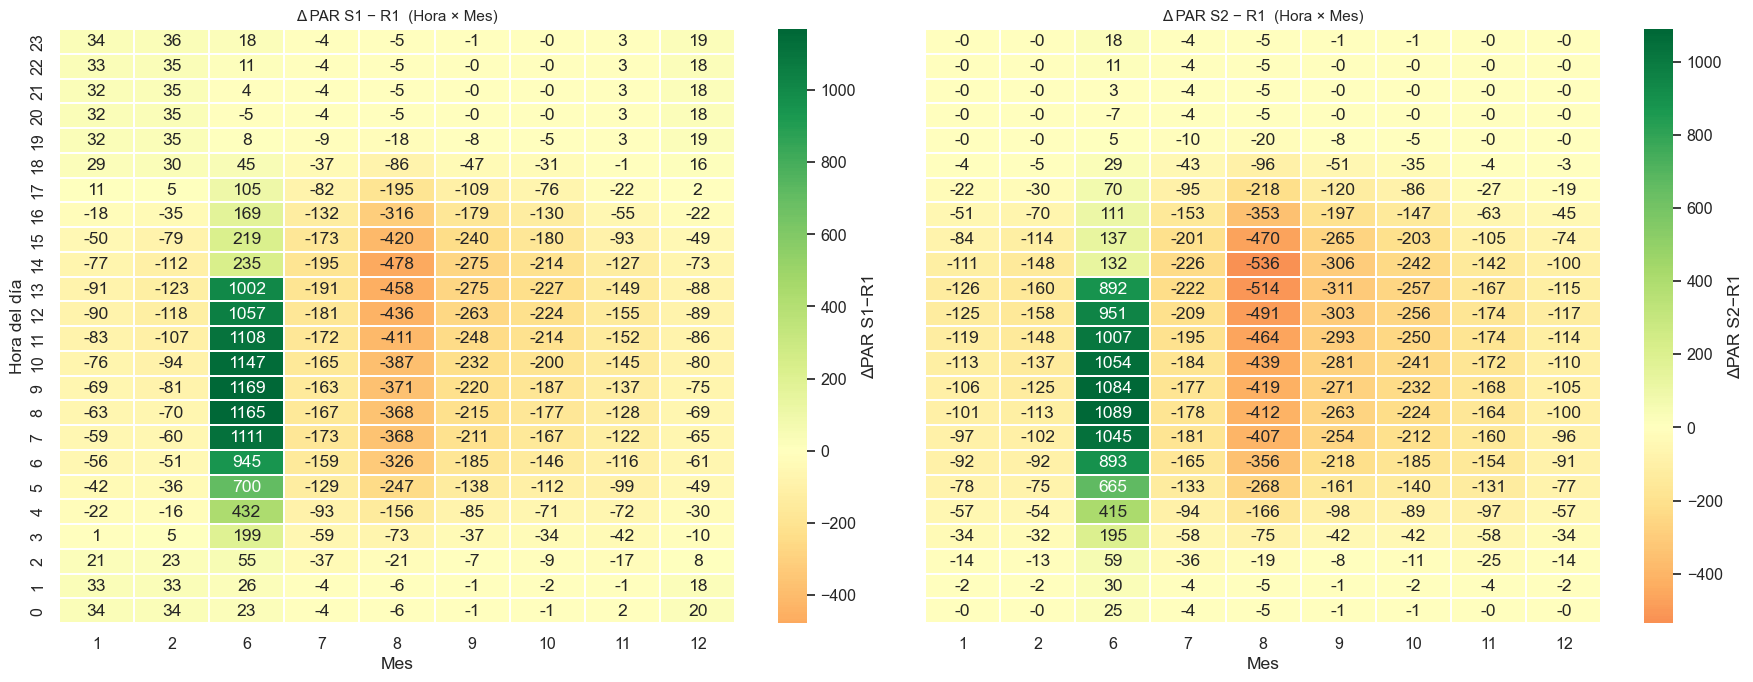


╔══════════════════════════════════════════════════════════════╗
║  VEREDICTO H2                                                ║
║  ✅ CONFIRMADA: S1 y S2 tienen patrones de PAR distintos.   ║
║     Su geometría de sombra es diferente entre sí.           ║
╚══════════════════════════════════════════════════════════════╝


In [21]:
# ── H2.2: Mapa de calor del Delta PAR por hora × mes ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, col, zona in zip(axes, ['Delta_PAR_S1', 'Delta_PAR_S2'], ['S1', 'S2']):
    pivot = df.pivot_table(values=col, index='Hora', columns='Mes', aggfunc='mean')
    sns.heatmap(pivot, cmap='RdYlGn', center=0, annot=True, fmt='.0f',
                cbar_kws={'label': f'ΔPAR {zona}−R1'}, ax=ax, linewidths=0.3)
    ax.set_title(f'Δ PAR {zona} − R1  (Hora × Mes)', fontsize=11)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Hora del día' if ax == axes[0] else '')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/H2_heatmap_delta_PAR.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("╔══════════════════════════════════════════════════════════════╗")
print("║  VEREDICTO H2                                                ║")
if p_s1s2 < 0.01 and asimetria_hora > 0.05:
    print("║  ✅ CONFIRMADA: S1 y S2 tienen patrones de PAR distintos.   ║")
    print("║     Su geometría de sombra es diferente entre sí.           ║")
elif p_s1s2 < 0.01:
    print("║  ⚠️  PARCIAL: hay diferencia estadística pero el patrón     ║")
    print("║     horario es similar — pueden tener distancia diferente   ║")
    print("║     pero la misma geometría relativa al tracker.            ║")
else:
    print("║  ❌ DUDOSA: S1 y S2 se comportan de forma muy similar.      ║")
print("╚══════════════════════════════════════════════════════════════╝")

---
## H3 — Existe un único ángulo de control (todos los trackers se mueven igual)

**Predicción:** Si el cliente tiene razón en que "totes les plaques es mouen igual", la correlación entre cualquier par de trackers debe ser **prácticamente 1.0**, y la diferencia entre ellos debe ser estadísticamente nula o un offset fijo (si hay error de calibración).

Trackers disponibles en el dataset: ['tracker_angles__tracker_M01 (actual)', 'tracker_angles__tracker_M02 (actual)', 'tracker_angles__tracker_M03 (actual)', 'tracker_angles__tracker_M04 (actual)', 'tracker_angles__tracker_M05 (actual)', 'tracker_angles__tracker_M06 (actual)', 'tracker_angles__tracker_M07 (actual)', 'tracker_angles__tracker_M08 (actual)', 'tracker_angles__tracker_M09 (actual)', 'tracker_angles__tracker_M10 (actual)']


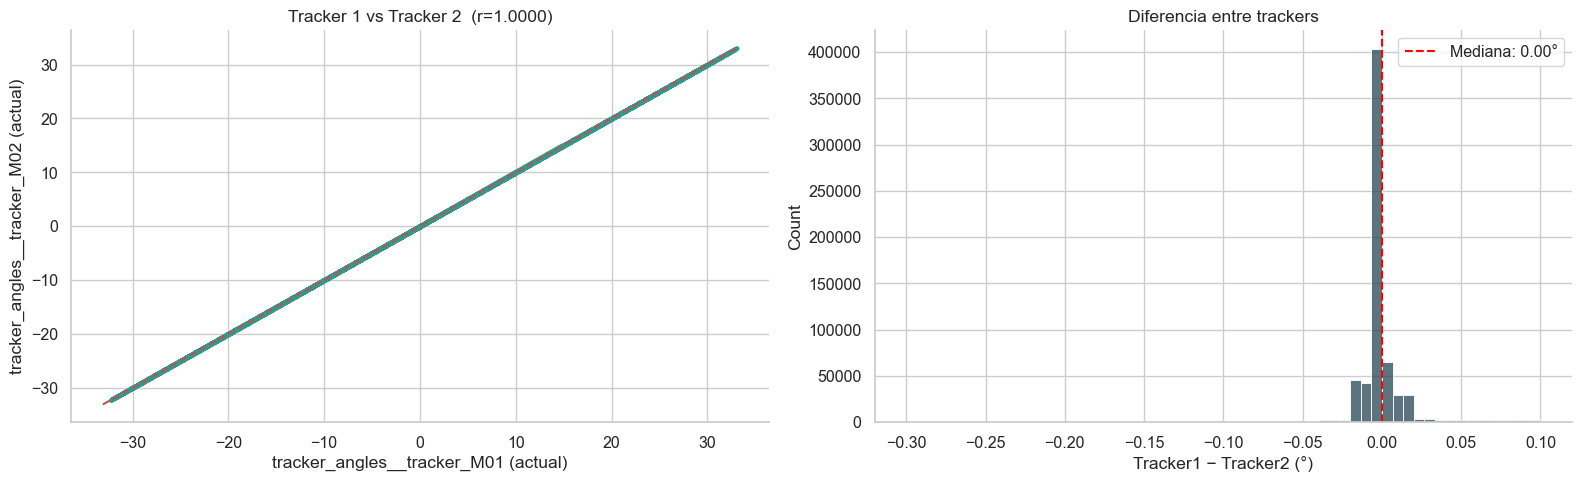

Matriz de correlaciones entre trackers:
                                      tracker_angles__tracker_M01 (actual)  \
tracker_angles__tracker_M01 (actual)                                   1.0   
tracker_angles__tracker_M02 (actual)                                   1.0   
tracker_angles__tracker_M03 (actual)                                   1.0   
tracker_angles__tracker_M04 (actual)                                   1.0   
tracker_angles__tracker_M05 (actual)                                   1.0   
tracker_angles__tracker_M06 (actual)                                   1.0   
tracker_angles__tracker_M07 (actual)                                   1.0   
tracker_angles__tracker_M08 (actual)                                   1.0   
tracker_angles__tracker_M09 (actual)                                   1.0   
tracker_angles__tracker_M10 (actual)                                   1.0   

                                      tracker_angles__tracker_M02 (actual)  \
tracker_angles__tracker

In [22]:
# ── H3: Correlación entre trackers ────────────────────────────────────────
print(f"Trackers disponibles en el dataset: {tracker_cols}")

if len(tracker_cols) < 2:
    print("Solo hay un tracker en el dataset. H3 no se puede testar directamente.")
    print("Procedemos a comparar el tracker con el ángulo solar teórico (pvlib).")
    
    # Comparación tracker vs ángulo solar teórico
    try:
        import pvlib
        loc = pvlib.location.Location(latitude=41.5, longitude=2.0,
                                       tz='Europe/Madrid', altitude=100)
        ts = df.index.tz_localize('Europe/Madrid', ambiguous='NaT', nonexistent='NaT')
        ts = ts.dropna()
        solar_pos = loc.get_solarposition(ts)
        tracking = pvlib.tracking.singleaxis(
            apparent_zenith=solar_pos['apparent_zenith'],
            solar_azimuth=solar_pos['azimuth'],
            max_angle=60, backtrack=True, gcr=0.35
        )
        angulo_teorico = tracking['tracker_theta']
        angulo_teorico.index = angulo_teorico.index.tz_localize(None)
        
        df_tracker = pd.DataFrame({
            'real': df[tracker_cols[0]],
            'teorico': angulo_teorico
        }).dropna()
        
        corr_teo = df_tracker['real'].corr(df_tracker['teorico'])
        rmse_teo = np.sqrt(((df_tracker['real'] - df_tracker['teorico'])**2).mean())
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        ax = axes[0]
        ax.scatter(df_tracker['teorico'], df_tracker['real'],
                   alpha=0.05, s=3, color=COLORS['S1'])
        lim = max(df_tracker.abs().max())
        ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='Ideal (y=x)')
        ax.set_title(f'Tracker real vs teórico solar  (r={corr_teo:.4f})')
        ax.set_xlabel('Ángulo solar teórico (pvlib)')
        ax.set_ylabel('Ángulo tracker medido')
        ax.legend()
        ax.set_xlim(-70, 70); ax.set_ylim(-70, 70)
        
        residuo = df_tracker['real'] - df_tracker['teorico']
        ax = axes[1]
        sns.histplot(residuo.dropna(), bins=60, ax=ax, color=COLORS['S2'])
        ax.axvline(residuo.median(), color='red', linestyle='--',
                   label=f'Mediana: {residuo.median():.1f}°')
        ax.set_title('Residuo: tracker real − teórico')
        ax.set_xlabel('Residuo (°)')
        ax.legend()
        
        plt.tight_layout()
        plt.savefig('outputs/H3_tracker_vs_solar.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n  Correlación tracker real vs solar teórico: r = {corr_teo:.4f}")
        print(f"  RMSE: {rmse_teo:.2f}°")
        print(f"  Offset sistemático (mediana residuo): {residuo.median():.2f}°")
        
    except ImportError:
        print("pvlib no disponible. Instalar con: pip install pvlib")

else:
    # Múltiples trackers: comparación directa entre ellos
    df_trackers = df[tracker_cols].dropna()
    corr_matrix = df_trackers.corr()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    ax = axes[0]
    t1, t2 = tracker_cols[0], tracker_cols[1]
    ax.scatter(df_trackers[t1], df_trackers[t2], alpha=0.1, s=3, color=COLORS['S1'])
    lim = max(df_trackers[[t1, t2]].abs().max())
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5)
    ax.set_title(f'Tracker 1 vs Tracker 2  (r={corr_matrix.iloc[0,1]:.4f})')
    ax.set_xlabel(t1)
    ax.set_ylabel(t2)
    
    ax = axes[1]
    diff = df_trackers[t1] - df_trackers[t2]
    sns.histplot(diff.dropna(), bins=60, ax=ax, color=COLORS['S2'])
    ax.axvline(diff.median(), color='red', linestyle='--',
               label=f'Mediana: {diff.median():.2f}°')
    ax.set_title('Diferencia entre trackers')
    ax.set_xlabel('Tracker1 − Tracker2 (°)')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('outputs/H3_comparacion_trackers.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Matriz de correlaciones entre trackers:")
    print(corr_matrix.round(4))

print()
print("╔══════════════════════════════════════════════════════════════╗")
print("║  VEREDICTO H3                                                ║")
print("║  Interpretar según r y RMSE arriba:                          ║")
print("║  r > 0.99 y RMSE < 3° → ✅ Control unificado confirmado      ║")
print("║  r > 0.95 y offset fijo → ⚠️  Unificado con sesgo calibrac.  ║")
print("║  r < 0.95               → ❌ Revisar hipótesis               ║")
print("╚══════════════════════════════════════════════════════════════╝")

---
## H4 — El efecto de sombra es asimétrico entre S1 y S2

**Predicción:** Si S1 y S2 están a lados opuestos del eje de rotación (o a distancias distintas), cuando el tracker rota hacia el este (mañana, ángulo negativo) **una zona se sombrece más que la otra**, y el efecto se invierte por la tarde. Esto se verá como una **correlación negativa** entre `Delta_PAR_S1` y `Delta_PAR_S2` a lo largo del día, o como curvas PAR vs ángulo simétricas pero invertidas en su mínimo.

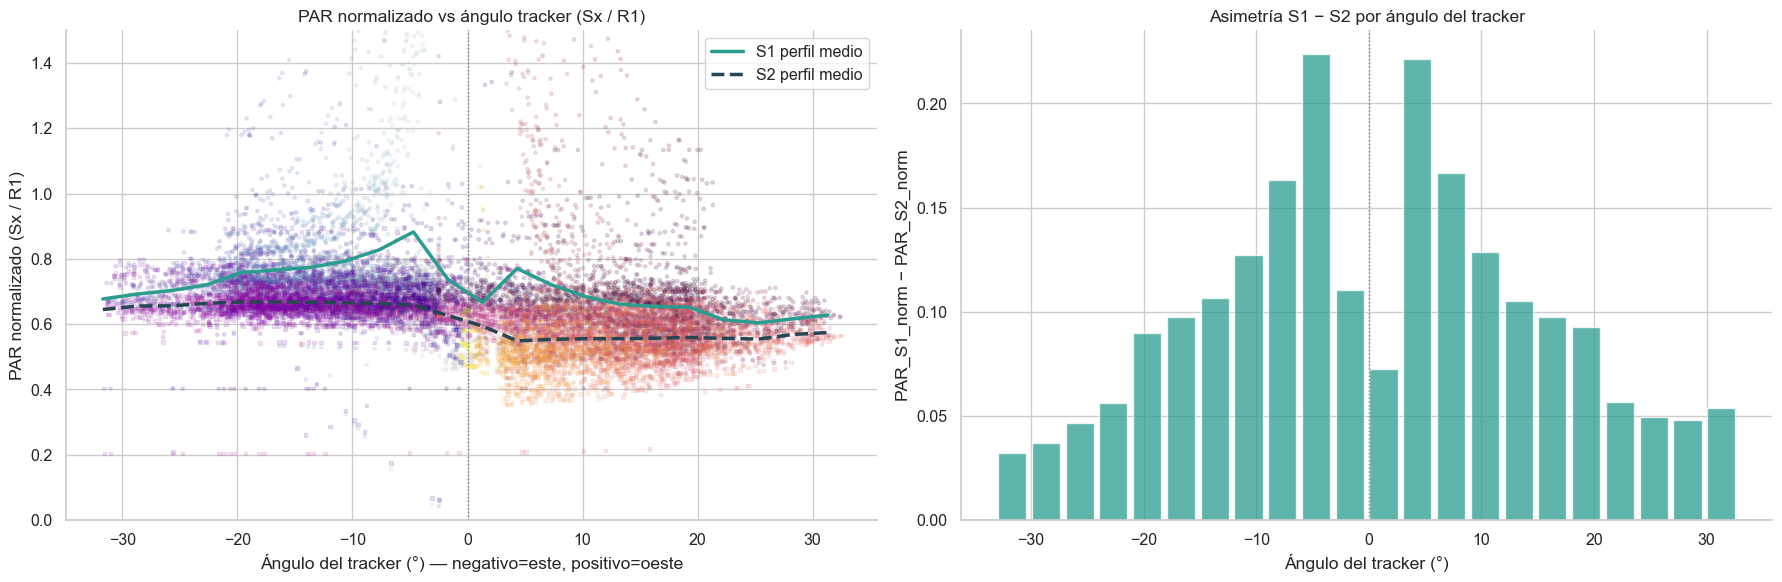

Asimetría media S1−S2 por período:
  Mañana  (ángulo < −10°): +0.093
  Mediodía (|ángulo| ≤ 10°): +0.165
  Tarde   (ángulo >  10°): +0.092


In [23]:
# ── H4.1: Huella óptica — PAR vs ángulo del tracker ───────────────────────
df_h4 = df[es_dia].dropna(subset=['Angulo_ref', 'PAR_S1', 'PAR_S2', 'PAR_R1', 'Hora']).copy()

# Normalizamos PAR por el de R1 (elimina efecto de nubosidad)
df_h4['PAR_S1_norm'] = df_h4['PAR_S1'] / df_h4['PAR_R1'].clip(lower=10)
df_h4['PAR_S2_norm'] = df_h4['PAR_S2'] / df_h4['PAR_R1'].clip(lower=10)

# Media por bin de ángulo
bins = np.arange(df_h4['Angulo_ref'].min() - 1, df_h4['Angulo_ref'].max() + 2, 3)
df_h4['ang_bin'] = pd.cut(df_h4['Angulo_ref'], bins=bins)
perfil = df_h4.groupby('ang_bin', observed=True)[['PAR_S1_norm', 'PAR_S2_norm']].agg(['mean', 'std'])
perfil.columns = ['_'.join(c) for c in perfil.columns]
perfil['angulo_centro'] = [iv.mid for iv in perfil.index]
perfil = perfil.dropna(subset=['angulo_centro'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel izquierdo: scatter + perfil medio
ax = axes[0]
sample_h4 = df_h4.sample(min(8000, len(df_h4)), random_state=42)
ax.scatter(sample_h4['Angulo_ref'], sample_h4['PAR_S1_norm'],
           c=sample_h4['Hora'], cmap='twilight', alpha=0.15, s=6, label='_nolegend_')
ax.scatter(sample_h4['Angulo_ref'], sample_h4['PAR_S2_norm'],
           c=sample_h4['Hora'], cmap='plasma', alpha=0.12, s=6, marker='s', label='_nolegend_')
ax.plot(perfil['angulo_centro'], perfil['PAR_S1_norm_mean'],
        color=COLORS['S1'], linewidth=2.5, label='S1 perfil medio')
ax.plot(perfil['angulo_centro'], perfil['PAR_S2_norm_mean'],
        color=COLORS['S2'], linewidth=2.5, linestyle='--', label='S2 perfil medio')
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.set_title('PAR normalizado vs ángulo tracker (Sx / R1)')
ax.set_xlabel('Ángulo del tracker (°) — negativo=este, positivo=oeste')
ax.set_ylabel('PAR normalizado (Sx / R1)')
ax.legend()
ax.set_ylim(0, 1.5)

# Panel derecho: diferencia S1 − S2 normalizada vs ángulo
ax = axes[1]
df_h4['asimetria'] = df_h4['PAR_S1_norm'] - df_h4['PAR_S2_norm']
asim_perfil = df_h4.groupby('ang_bin', observed=True)['asimetria'].mean()
angulos_mid = [iv.mid for iv in asim_perfil.index]

ax.bar(angulos_mid, asim_perfil.values, width=2.5,
       color=[COLORS['S1'] if v > 0 else COLORS['S2'] for v in asim_perfil.values],
       alpha=0.75, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.set_title('Asimetría S1 − S2 por ángulo del tracker')
ax.set_xlabel('Ángulo del tracker (°)')
ax.set_ylabel('PAR_S1_norm − PAR_S2_norm')

plt.tight_layout()
plt.savefig('outputs/H4_asimetria_sombra.png', dpi=150, bbox_inches='tight')
plt.show()

# Cuantificar asimetría mañana vs tarde
manana  = df_h4[df_h4['Angulo_ref'] < -10]['asimetria'].mean()
mediodia = df_h4[df_h4['Angulo_ref'].abs() <= 10]['asimetria'].mean()
tarde   = df_h4[df_h4['Angulo_ref'] > 10]['asimetria'].mean()

print(f"Asimetría media S1−S2 por período:")
print(f"  Mañana  (ángulo < −10°): {manana:+.3f}")
print(f"  Mediodía (|ángulo| ≤ 10°): {mediodia:+.3f}")
print(f"  Tarde   (ángulo >  10°): {tarde:+.3f}")

# Test: ¿la asimetría cambia de signo entre mañana y tarde?
cambio_signo = (manana * tarde) < 0

In [24]:
print()
print("╔══════════════════════════════════════════════════════════════╗")
print("║  VEREDICTO H4                                                ║")
if cambio_signo:
    print("║  ✅ CONFIRMADA: La asimetría S1−S2 cambia de signo entre    ║")
    print("║     mañana y tarde. S1 y S2 están a lados opuestos del     ║")
    print("║     eje del tracker (o a distancias asimétricas).           ║")
    if manana > 0:
        print("║     Interpretación: S1 más iluminada por la mañana        ║")
        print("║     → S1 está al lado este de los paneles.                ║")
    else:
        print("║     Interpretación: S2 más iluminada por la mañana        ║")
        print("║     → S2 está al lado este de los paneles.                ║")
else:
    print("║  ❌ NO CONFIRMADA: la asimetría no cambia de signo.         ║")
    print("║     S1 y S2 podrían estar a distintas distancias del eje    ║")
    print("║     pero en el mismo lado.                                  ║")
print("╚══════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════╗
║  VEREDICTO H4                                                ║
║  ❌ NO CONFIRMADA: la asimetría no cambia de signo.         ║
║     S1 y S2 podrían estar a distintas distancias del eje    ║
║     pero en el mismo lado.                                  ║
╚══════════════════════════════════════════════════════════════╝


---
## H5 — El ángulo del tracker afecta de forma medible y diferente la radiación en S1 y S2

**Predicción:** Existe un ángulo óptimo (distinto para S1 y S2) que maximiza PAR_Sx. Este ángulo puede diferir del óptimo de irradiancia PV. Esto es la base del problema de RL: hay un trade-off entre maximizar energía eléctrica (seguir el sol) y maximizar PAR bajo las placas.

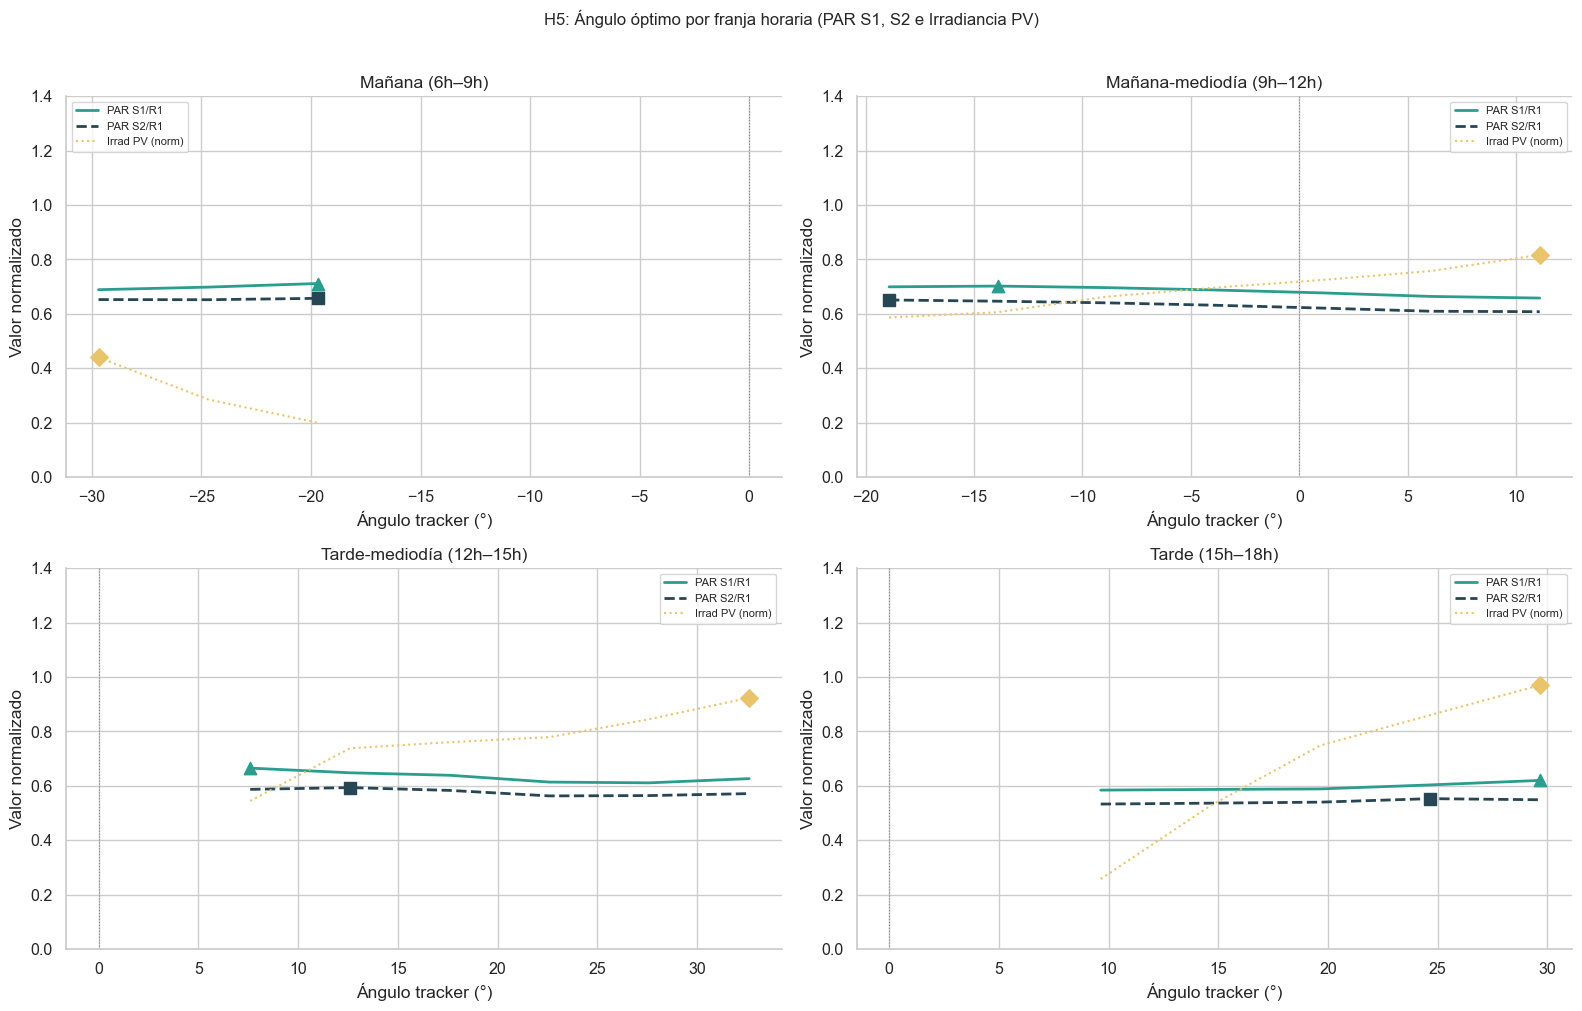

Ángulos óptimos por franja y variable:
Variable         Irrad_n  PAR_S1_n  PAR_S2_n
Franja                                      
Mañana             -29.7     -19.7     -19.7
Mañana-mediodía     11.1     -13.9     -18.9
Tarde               29.6      29.6      24.6
Tarde-mediodía      32.6       7.6      12.6


In [25]:
# ── H5.1: Ángulo óptimo por franja horaria ────────────────────────────────
franjas = [(6, 9, 'Mañana'), (9, 12, 'Mañana-mediodía'),
           (12, 15, 'Tarde-mediodía'), (15, 18, 'Tarde')]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

resultados_optimo = []

for ax, (h_ini, h_fin, nombre) in zip(axes, franjas):
    mask = (df['Hora'] >= h_ini) & (df['Hora'] < h_fin) & es_dia
    sub = df[mask].dropna(subset=['Angulo_ref', 'PAR_S1', 'PAR_S2', 'Irrad_PV'])
    if len(sub) < 50:
        ax.set_title(f'{nombre}: datos insuficientes')
        continue

    # Media por bin de ángulo (normalizado por R1)
    sub = sub.copy()
    sub['PAR_S1_n'] = sub['PAR_S1'] / sub['PAR_R1'].clip(lower=10)
    sub['PAR_S2_n'] = sub['PAR_S2'] / sub['PAR_R1'].clip(lower=10)
    sub['Irrad_n']  = sub['Irrad_PV'] / sub['Irrad_PV'].max()

    bins_h = np.arange(sub['Angulo_ref'].min(), sub['Angulo_ref'].max() + 5, 5)
    sub['ang_bin'] = pd.cut(sub['Angulo_ref'], bins=bins_h)
    g = sub.groupby('ang_bin', observed=True)[['PAR_S1_n', 'PAR_S2_n', 'Irrad_n']].mean()
    g['ang_mid'] = [iv.mid for iv in g.index]
    g = g.dropna()

    ax.plot(g['ang_mid'], g['PAR_S1_n'], color=COLORS['S1'], lw=2, label='PAR S1/R1')
    ax.plot(g['ang_mid'], g['PAR_S2_n'], color=COLORS['S2'], lw=2, linestyle='--', label='PAR S2/R1')
    ax.plot(g['ang_mid'], g['Irrad_n'],  color='#E9C46A', lw=1.5, linestyle=':', label='Irrad PV (norm)')

    # Marcar óptimos
    for col, c, marker in [('PAR_S1_n', COLORS['S1'], '^'), ('PAR_S2_n', COLORS['S2'], 's'), ('Irrad_n', '#E9C46A', 'D')]:
        if g[col].notna().sum() > 0:
            opt_ang = g.loc[g[col].idxmax(), 'ang_mid']
            opt_val = g[col].max()
            ax.scatter(opt_ang, opt_val, color=c, s=80, zorder=5, marker=marker)
            resultados_optimo.append({'Franja': nombre, 'Variable': col, 'Angulo_opt': opt_ang})

    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_title(f'{nombre} ({h_ini}h–{h_fin}h)')
    ax.set_xlabel('Ángulo tracker (°)')
    ax.set_ylabel('Valor normalizado')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.4)

plt.suptitle('H5: Ángulo óptimo por franja horaria (PAR S1, S2 e Irradiancia PV)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('outputs/H5_angulo_optimo_franja.png', dpi=150, bbox_inches='tight')
plt.show()

df_opt = pd.DataFrame(resultados_optimo)
if not df_opt.empty:
    print("Ángulos óptimos por franja y variable:")
    print(df_opt.pivot(index='Franja', columns='Variable', values='Angulo_opt').round(1).to_string())

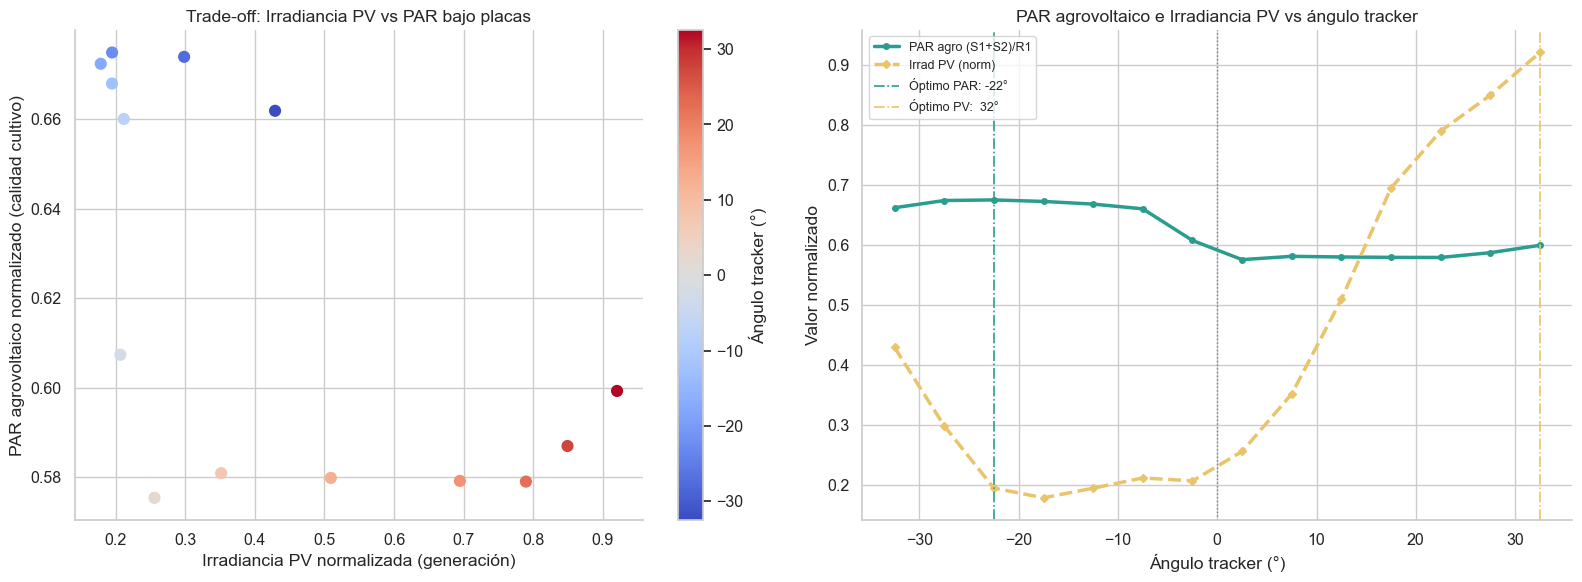

Ángulo óptimo para PAR agrovoltaico (global): -22°
Ángulo óptimo para Irradiancia PV (global):   32°
Divergencia entre objetivos: 55°

╔══════════════════════════════════════════════════════════════╗
║  VEREDICTO H5                                                ║
║  ✅ CONFIRMADA: El ángulo óptimo para cultivo ≠ óptimo PV.  ║
║     Existe un trade-off real que justifica el problema RL.  ║
║     La política óptima NO es simplemente seguir al sol.     ║
╚══════════════════════════════════════════════════════════════╝


In [26]:
# ── H5.2: Trade-off PAR vs Irradiancia — la curva de Pareto del tracker ───
df_h5 = df[es_dia].dropna(subset=['Angulo_ref', 'PAR_S1', 'PAR_S2', 'PAR_R1', 'Irrad_PV']).copy()
df_h5['PAR_agro'] = (df_h5['PAR_S1'] + df_h5['PAR_S2']) / 2  # media de zonas bajo placas
df_h5['PAR_agro_n'] = df_h5['PAR_agro'] / df_h5['PAR_R1'].clip(lower=10)
df_h5['Irrad_n']    = df_h5['Irrad_PV'] / df_h5['Irrad_PV'].max()

bins_h5 = np.arange(-65, 66, 5)
df_h5['ang_bin'] = pd.cut(df_h5['Angulo_ref'], bins=bins_h5)
trade = df_h5.groupby('ang_bin', observed=True)[['PAR_agro_n', 'Irrad_n']].mean()
trade['ang_mid'] = [iv.mid for iv in trade.index]
trade = trade.dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva de trade-off directa
ax = axes[0]
sc = ax.scatter(trade['Irrad_n'], trade['PAR_agro_n'],
                c=trade['ang_mid'], cmap='coolwarm', s=60, zorder=3)
plt.colorbar(sc, ax=ax, label='Ángulo tracker (°)')
ax.set_title('Trade-off: Irradiancia PV vs PAR bajo placas')
ax.set_xlabel('Irradiancia PV normalizada (generación)')
ax.set_ylabel('PAR agrovoltaico normalizado (calidad cultivo)')

# Tanto Irradiancia como PAR vs ángulo — superpuestos
ax = axes[1]
ax.plot(trade['ang_mid'], trade['PAR_agro_n'],
        color=COLORS['S1'], lw=2.5, marker='o', markersize=4, label='PAR agro (S1+S2)/R1')
ax.plot(trade['ang_mid'], trade['Irrad_n'],
        color='#E9C46A', lw=2.5, marker='D', markersize=4, linestyle='--', label='Irrad PV (norm)')
ax.axvline(0, color='gray', linestyle=':', linewidth=1)

# Marcar óptimos
opt_par   = trade.loc[trade['PAR_agro_n'].idxmax(), 'ang_mid']
opt_irrad = trade.loc[trade['Irrad_n'].idxmax(), 'ang_mid']
ax.axvline(opt_par,   color=COLORS['S1'], linestyle='-.', lw=1.2, label=f'Óptimo PAR: {opt_par:.0f}°')
ax.axvline(opt_irrad, color='#E9C46A',    linestyle='-.', lw=1.2, label=f'Óptimo PV:  {opt_irrad:.0f}°')

ax.set_title('PAR agrovoltaico e Irradiancia PV vs ángulo tracker')
ax.set_xlabel('Ángulo tracker (°)')
ax.set_ylabel('Valor normalizado')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/H5_tradeoff_PAR_PV.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ángulo óptimo para PAR agrovoltaico (global): {opt_par:.0f}°")
print(f"Ángulo óptimo para Irradiancia PV (global):   {opt_irrad:.0f}°")
print(f"Divergencia entre objetivos: {abs(opt_par - opt_irrad):.0f}°")

print()
print("╔══════════════════════════════════════════════════════════════╗")
print("║  VEREDICTO H5                                                ║")
if abs(opt_par - opt_irrad) > 5:
    print("║  ✅ CONFIRMADA: El ángulo óptimo para cultivo ≠ óptimo PV.  ║")
    print("║     Existe un trade-off real que justifica el problema RL.  ║")
    print("║     La política óptima NO es simplemente seguir al sol.     ║")
else:
    print("║  ⚠️  MATIZADA: Los óptimos son muy similares. El trade-off   ║")
    print("║     puede ser más sutil o depender de la hora del día.      ║")
print("╚══════════════════════════════════════════════════════════════╝")

---
## Resumen de Hipótesis

In [27]:
# ── Tabla resumen de hallazgos para el informe ────────────────────────────
resumen = [
    ('H1', 'R1 sin placas',         'PAR_R1 >> PAR_S1, PAR_S2 en horas diurnas + test t'),
    ('H2', 'S1 ≠ S2 geométricamente','PAR_S1/PAR_S2 ≠ 1 con patrón horario diferente'),
    ('H3', 'Control tracker único',  'Correlación entre trackers o tracker vs solar teórico'),
    ('H4', 'Asimetría de sombra',    'Cambio de signo asimetría S1−S2 entre mañana y tarde'),
    ('H5', 'Trade-off PAR vs PV',    'Ángulo óptimo PAR ≠ ángulo óptimo irradiancia PV'),
]

print("═" * 75)
print(f"{'ID':4} {'Hipótesis':28} {'Cómo se testó'}")
print("═" * 75)
for h_id, h_nombre, h_test in resumen:
    print(f"{h_id:4} {h_nombre:28} {h_test}")
print("═" * 75)
print()
print("Outputs guardados en outputs/:")
print("  H1_PAR_por_zona.png")
print("  H1_temperatura_suelo.png")
print("  H2_geometria_zonas.png")
print("  H2_heatmap_delta_PAR.png")
print("  H3_tracker_vs_solar.png  (o H3_comparacion_trackers.png)")
print("  H4_asimetria_sombra.png")
print("  H5_angulo_optimo_franja.png")
print("  H5_tradeoff_PAR_PV.png")

═══════════════════════════════════════════════════════════════════════════
ID   Hipótesis                    Cómo se testó
═══════════════════════════════════════════════════════════════════════════
H1   R1 sin placas                PAR_R1 >> PAR_S1, PAR_S2 en horas diurnas + test t
H2   S1 ≠ S2 geométricamente      PAR_S1/PAR_S2 ≠ 1 con patrón horario diferente
H3   Control tracker único        Correlación entre trackers o tracker vs solar teórico
H4   Asimetría de sombra          Cambio de signo asimetría S1−S2 entre mañana y tarde
H5   Trade-off PAR vs PV          Ángulo óptimo PAR ≠ ángulo óptimo irradiancia PV
═══════════════════════════════════════════════════════════════════════════

Outputs guardados en outputs/:
  H1_PAR_por_zona.png
  H1_temperatura_suelo.png
  H2_geometria_zonas.png
  H2_heatmap_delta_PAR.png
  H3_tracker_vs_solar.png  (o H3_comparacion_trackers.png)
  H4_asimetria_sombra.png
  H5_angulo_optimo_franja.png
  H5_tradeoff_PAR_PV.png
